In [3]:
# Load Table 2A baseline returns as a 3x4 NumPy matrix
import numpy as np

baseline_returns = np.array([
    [2.07, 1.49, 1.21, 1.44],  # Western
    [3.70, 3.11, 1.61, 2.74],  # Central
    [1.10, 1.72, 1.78, 1.96],  # Eastern
])



# 1. Recreating Mallory and Ando & Testing utiltiy functions. 
In this section we have 
- Recreating efficient frontier and optimal portfolios for linearly interpolated returns between the current and projected future returns in the paper. 

- Trying to see how the optimal portfolio compares when maximizing the expected utility functions with varying risk aversion parameter. Try with CRRA and mena-variance utility.



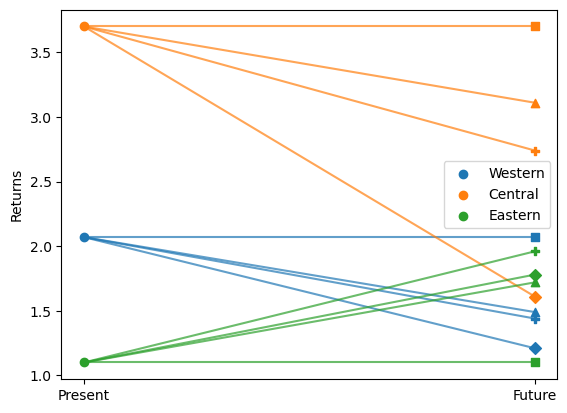

In [4]:
# Visualize historical vs future scenarios with connecting lines per region
import matplotlib.pyplot as plt
regions = ['Western', 'Central', 'Eastern']

historical_marker = 'o'  # Present value at x=0
scenario_markers = ['s', '^', 'D', 'P']  # Future markers for columns 0,1,2,3

for i, region in enumerate(regions):
    historical = baseline_returns[i][0]
    future_values = baseline_returns[i]

    # Plot the historical point and keep the color for matching future points/lines
    scatter = plt.scatter([0], [historical], marker=historical_marker, label=region)
    color = scatter.get_facecolor()[0]

    # Plot each future value with a marker based on its column index
    for j, f in enumerate(future_values):
        plt.scatter([1], [f], marker=scenario_markers[j], color=color)
        plt.plot([0, 1], [historical, f], color=color, alpha=0.7)

plt.xticks([0, 1], ['Present', 'Future'])
plt.ylabel('Returns')
plt.legend()
plt.show()


In [47]:
# make multiple timesteps returns for each region
# Load Table 2A baseline returns as a 3x4 NumPy matrix
import numpy as np

baseline_returns = np.array([
    [2.07, 1.49, 1.21, 1.44],  # Western
    [3.70, 3.11, 1.61, 2.74],  # Central
    [1.10, 1.72, 1.78, 1.96],  # Eastern
])

timesteps = 10
multi_timestep_returns = np.zeros((timesteps,) + baseline_returns.shape)
multi_timestep_returns[-1] = baseline_returns

multi_timestep_returns[0] = np.tile(baseline_returns[:, 0], (4, 1)).T  # stack 0th col 4 times
# linear interpolation between the historical 0th column and the final baseline returns
historical_col = baseline_returns[:, 0][:, np.newaxis]
for t in range(1, timesteps - 1):
    multi_timestep_returns[t] = historical_col + (baseline_returns - historical_col) * t / (timesteps - 1)


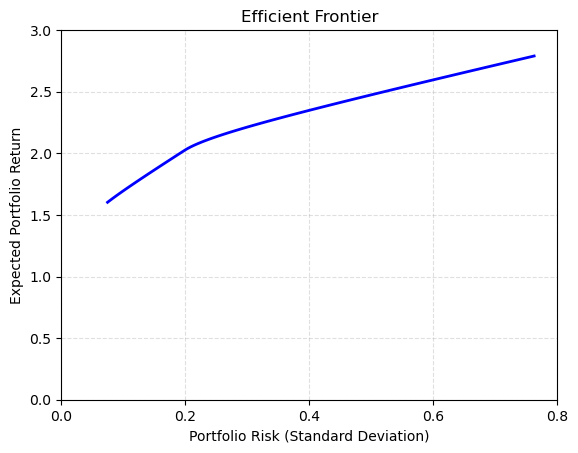

In [6]:
# test mpt solver on final returns data
from MPTsolver import MPTsolver
import matplotlib.pyplot as plt
import numpy as np

mpt = MPTsolver(multi_timestep_returns[-1])
frontier, weights = mpt.get_efficient_frontier(numportfolios=100)

# plot efficient frontier
plt.plot(frontier[:, 1], frontier[:, 0], 'b-', linewidth=2)
plt.xlabel('Portfolio Risk (Standard Deviation)')
plt.ylabel('Expected Portfolio Return')
plt.title('Efficient Frontier')

# Set ticks at fixed intervals
x_max = frontier[:, 1].max()
y_max = frontier[:, 0].max()
plt.xticks(np.arange(0, x_max + 0.2, 0.2))
plt.yticks(np.arange(0, y_max + 0.5, 0.5))

# Add grid lines
plt.grid(True, which='major', linestyle='--', alpha=0.4)

plt.show()




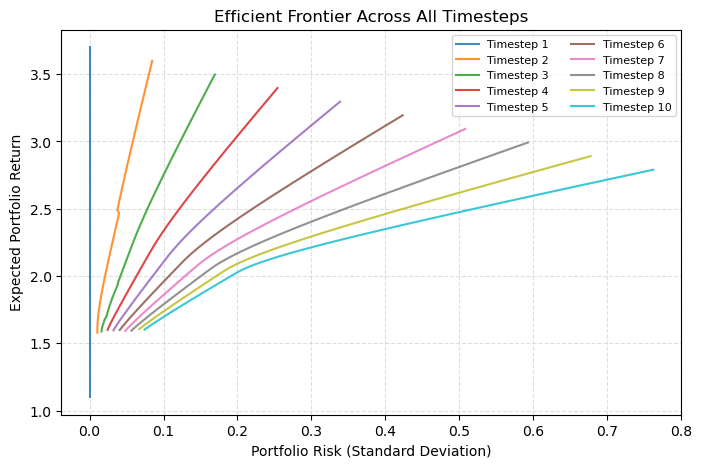

In [7]:
# Plot efficient frontier for every timestep
import numpy as np
import matplotlib.pyplot as plt
from MPTsolver import MPTsolver

all_frontiers = []
all_weights = []

plt.figure(figsize=(8, 5))
for t in range(multi_timestep_returns.shape[0]):
    mpt_t = MPTsolver(multi_timestep_returns[t])
    frontier_t, weights_t = mpt_t.get_efficient_frontier(numportfolios=100)
    all_frontiers.append(frontier_t)
    all_weights.append(weights_t)

    plt.plot(
        frontier_t[:, 1],
        frontier_t[:, 0],
        linewidth=1.5,
        alpha=0.85,
        label=f'Timestep {t + 1}'
    )

plt.xlabel('Portfolio Risk (Standard Deviation)')
plt.ylabel('Expected Portfolio Return')
plt.title('Efficient Frontier Across All Timesteps')
plt.grid(True, which='major', linestyle='--', alpha=0.4)
plt.legend(ncol=2, fontsize=8)
plt.show()

[[2.07 1.49 1.21 1.44]
 [2.6  2.01 0.51 1.64]
 [1.1  1.72 1.78 1.96]]


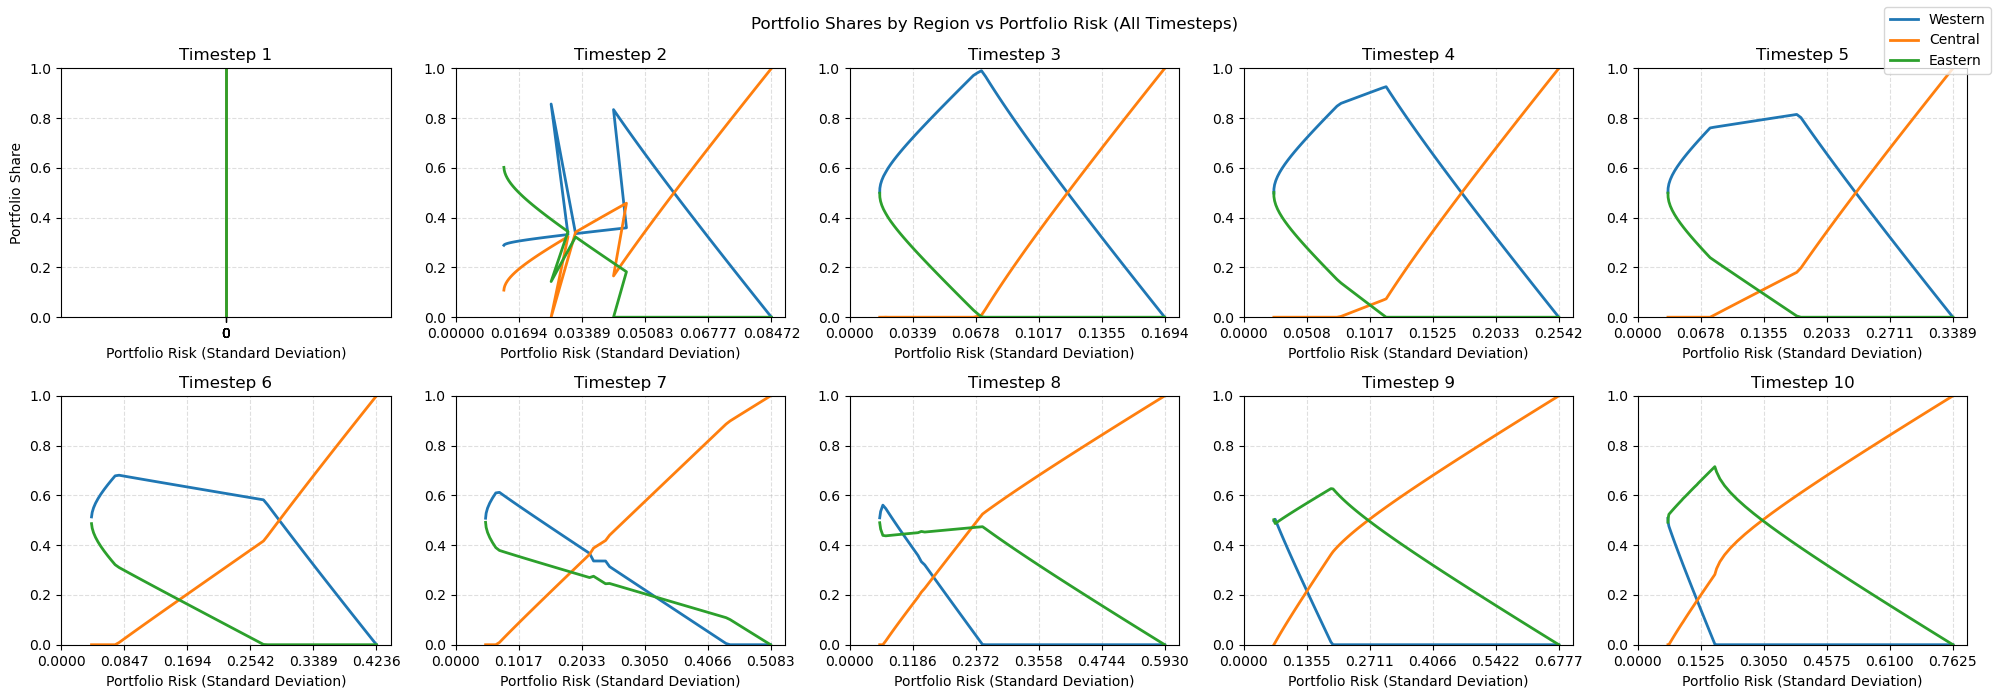

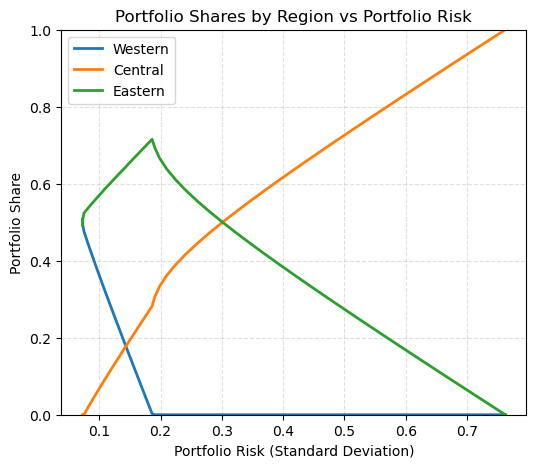

In [55]:
# Plot portfolio shares across regions vs risk for selected timesteps
import numpy as np
import matplotlib.pyplot as plt
from MPTsolver import MPTsolver

# load ando data

baseline_returns = np.array([
    [2.07, 1.49, 1.21, 1.44],  # Western
    [3.70, 3.11, 1.61, 2.74],  # Central
    [1.10, 1.72, 1.78, 1.96],  # Eastern
])
baseline_returns[1] = baseline_returns[1] - 1.1  # altering central region values to make it more comparable
print(baseline_returns)
timesteps = 10
multi_timestep_returns = np.zeros((timesteps,) + baseline_returns.shape)
multi_timestep_returns[-1] = baseline_returns

multi_timestep_returns[0] = np.tile(baseline_returns[:, 0], (4, 1)).T  # stack 0th col 4 times
# linear interpolation between the historical 0th column and the final baseline returns
historical_col = baseline_returns[:, 0][:, np.newaxis]
for t in range(1, timesteps - 1):
    multi_timestep_returns[t] = historical_col + (baseline_returns - historical_col) * t / (timesteps - 1)


# Recompute if Cell 5 was not run
if 'all_frontiers' not in globals() or 'all_weights' not in globals() or len(all_frontiers) != multi_timestep_returns.shape[0]:
    all_frontiers = []
    all_weights = []
    for t in range(multi_timestep_returns.shape[0]):
        mpt_t = MPTsolver(multi_timestep_returns[t])
        frontier_t, weights_t = mpt_t.get_efficient_frontier(numportfolios=100)
        all_frontiers.append(frontier_t)
        all_weights.append(weights_t)

regions = ['Western', 'Central', 'Eastern']
n_steps = multi_timestep_returns.shape[0]

# Plot all timesteps (1-based labels for display)
featured_timesteps = list(range(1, n_steps + 1))
selected_timesteps = [t - 1 for t in featured_timesteps]
titles = [f'Timestep {t}' for t in featured_timesteps]

# Common y-axis ticks for every subplot
y_ticks = np.arange(0, 1.01, 0.2)

# Build a grid layout that scales with number of timesteps
n_cols = 5
n_rows = int(np.ceil(len(selected_timesteps) / n_cols))
fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(4 * n_cols, 3.5 * n_rows),
    sharey=True,
    sharex=False
    )
axes = np.atleast_1d(axes).ravel()

for ax, t_idx, title in zip(axes, selected_timesteps, titles):
    frontier_t = all_frontiers[t_idx]
    weights_t = np.array(all_weights[t_idx])

    for r, region in enumerate(regions):
        ax.plot(frontier_t[:, 1], weights_t[:, r], linewidth=2, label=region)

    # Use per-subplot x ticks based on that subplot's risk range
    x_ticks = np.linspace(0, frontier_t[:, 1].max(), 6)
    ax.set_title(title)
    ax.set_xlabel('Portfolio Risk (Standard Deviation)')
    ax.set_ylim(0, 1)
    ax.set_xticks(x_ticks)
    ax.set_yticks(y_ticks)
    ax.tick_params(axis='both', labelbottom=True, labelleft=True)
    ax.grid(True, which='major', linestyle='--', alpha=0.4)

# Hide any unused axes in the grid
for ax in axes[len(selected_timesteps):]:
    ax.set_visible(False)

axes[0].set_ylabel('Portfolio Share')
fig.legend(regions, loc='upper right')
plt.suptitle('Portfolio Shares by Region vs Portfolio Risk (All Timesteps)')
plt.tight_layout()
plt.show()
# plot just the last step
plt.figure(figsize=(6, 5))
frontier_last = all_frontiers[-1]
weights_last = np.array(all_weights[-1])

for r, region in enumerate(regions):
    plt.plot(frontier_last[:, 1], weights_last[:, r], linewidth=2, label=region)

plt.xlabel('Portfolio Risk (Standard Deviation)')
plt.ylabel('Portfolio Share')
plt.title('Portfolio Shares by Region vs Portfolio Risk')
plt.ylim(0, 1)
plt.grid(True, which='major', linestyle='--', alpha=0.4)
plt.legend()
plt.show()



[[2.07 1.49 1.21 1.44]
 [3.7  3.11 1.61 2.74]
 [1.1  1.72 1.78 1.96]]


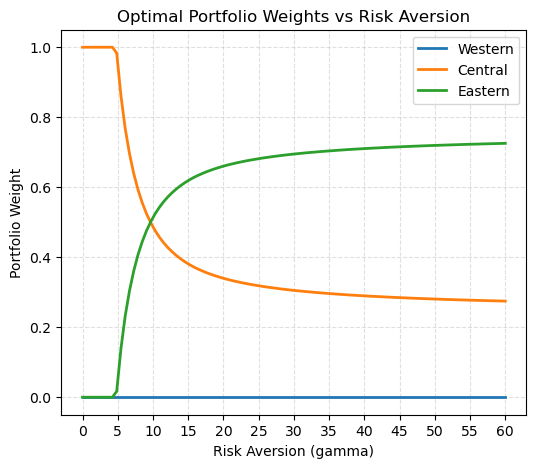

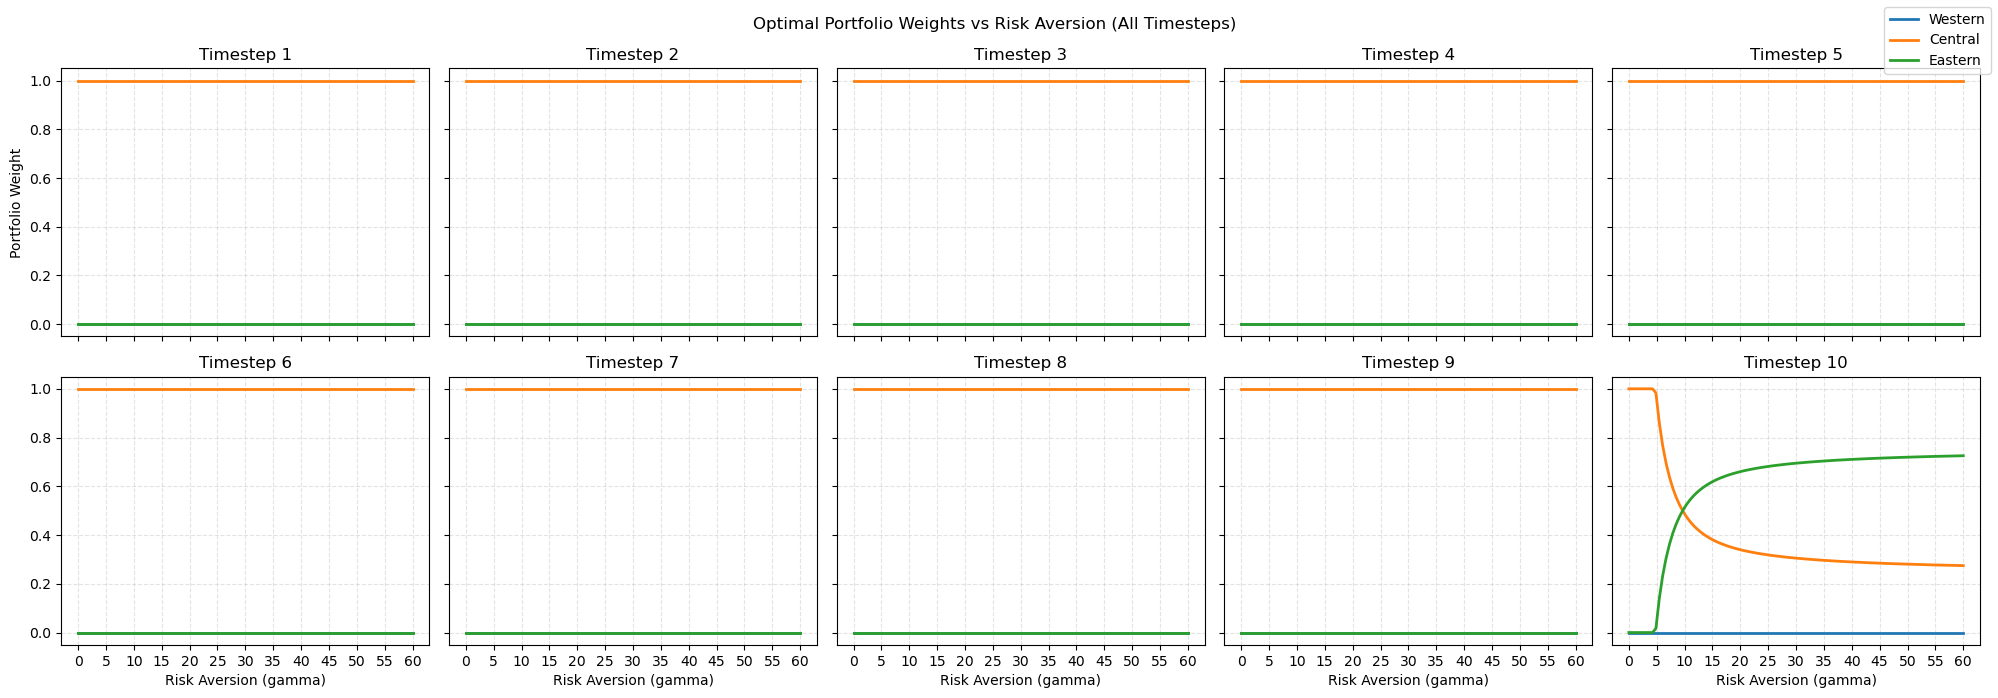

In [51]:
# utility maximization (crra utility) portfolio optimization
from utilitysolver import utilitysolver
import numpy as np
import matplotlib.pyplot as plt
# load ando data
central_adjustment = 0
baseline_returns = np.array([
    [2.07, 1.49, 1.21, 1.44],  # Western
    [3.70, 3.11, 1.61, 2.74],  # Central
    [1.10, 1.72, 1.78, 1.96],  # Eastern
])
baseline_returns[1] = baseline_returns[1] - central_adjustment # altering central region values to make it more comparable
print(baseline_returns)
timesteps = 10
multi_timestep_returns = np.zeros((timesteps,) + baseline_returns.shape)
multi_timestep_returns[-1] = baseline_returns

multi_timestep_returns[0] = np.tile(baseline_returns[:, 0], (4, 1)).T  # stack 0th col 4 times
# linear interpolation between the historical 0th column and the final baseline returns
historical_col = baseline_returns[:, 0][:, np.newaxis]
for t in range(1, timesteps - 1):
    multi_timestep_returns[t] = historical_col + (baseline_returns - historical_col) * t / (timesteps - 1)


ra_range = np.linspace(0, 60, 100)
weights_over_ra = []
max_u_over_ra = []
selected_timestep = 10 - 1  # zero-based index for the last timestep

for ra in ra_range:
    solver = utilitysolver(risk_aversion=ra)
    max_u, w = solver.max_utility(multi_timestep_returns[selected_timestep])
    #print(f"Risk aversion: {ra}")
    #print("Max expected utility:", max_u)
    #print("Optimal weights:", w)
    #print('\n')

    max_u_over_ra.append(max_u)
    weights_over_ra.append(w)

weights_over_ra = np.array(weights_over_ra)  # shape: (len(ra_range), 3)
max_u_over_ra = np.array(max_u_over_ra)    # shape: (len(ra_range),)
regions = ['Western', 'Central', 'Eastern']
 
plt.figure(figsize=(6, 5))
for i, region in enumerate(regions):
    plt.plot(ra_range, weights_over_ra[:, i], linewidth=2, label=region)

# Set x-axis major ticks at increments of 5
x_min = np.floor(ra_range.min() / 5) * 5
x_max = np.ceil(ra_range.max() / 5) * 5
plt.xticks(np.arange(x_min, x_max + 5, 5))

plt.xlabel('Risk Aversion (gamma)')
plt.ylabel('Portfolio Weight')
plt.title('Optimal Portfolio Weights vs Risk Aversion')
plt.grid(True, which='major', linestyle='--', alpha=0.4)
plt.legend()
plt.show()

# Additional figure: weights vs risk aversion for all timesteps (1-based labels)
n_steps = multi_timestep_returns.shape[0]
n_regions = len(regions)
all_weights_over_ra = np.zeros((n_steps, len(ra_range), n_regions))

for t_idx in range(n_steps):
    for r_idx, ra in enumerate(ra_range):
        solver = utilitysolver(risk_aversion=ra)
        _, w = solver.max_utility(multi_timestep_returns[t_idx])
        all_weights_over_ra[t_idx, r_idx, :] = w

n_cols = 5
n_rows = int(np.ceil(n_steps / n_cols))
fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(4 * n_cols, 3.5 * n_rows),
    sharex=True,
    sharey=True
    )
axes = np.atleast_1d(axes).ravel()

for t_idx in range(n_steps):
    ax = axes[t_idx]
    for i, region in enumerate(regions):
        ax.plot(ra_range, all_weights_over_ra[t_idx, :, i], linewidth=2, label=region)
    ax.set_title(f'Timestep {t_idx + 1}')
    ax.set_xticks(np.arange(x_min, x_max + 5, 5))
    ax.grid(True, which='major', linestyle='--', alpha=0.35)

for ax in axes[n_steps:]:
    ax.set_visible(False)

axes[0].set_ylabel('Portfolio Weight')
for ax in axes[-n_cols:]:
    if ax.get_visible():
        ax.set_xlabel('Risk Aversion (gamma)')

fig.legend(regions, loc='upper right')
plt.suptitle('Optimal Portfolio Weights vs Risk Aversion (All Timesteps)')
plt.tight_layout()
plt.show()

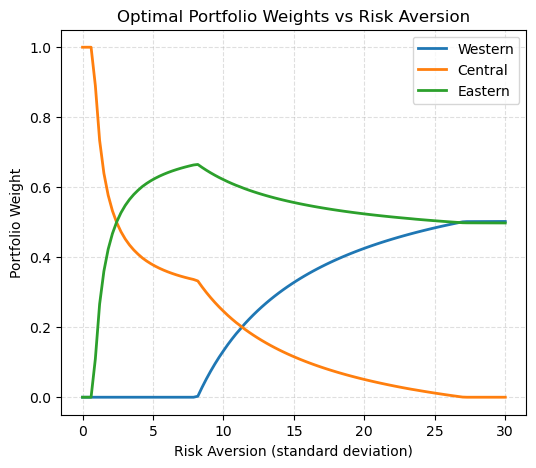

In [53]:
from utilitysolver2 import utilitysolver
import numpy as np
import matplotlib.pyplot as plt
baseline_returns = np.array([
    [2.07, 1.49, 1.21, 1.44],  # Western
    [3.70, 3.11, 1.61, 2.74],  # Central
    [1.10, 1.72, 1.78, 1.96],  # Eastern
])

timesteps = 1000
multi_timestep_returns = np.zeros((timesteps,) + baseline_returns.shape)
multi_timestep_returns[-1] = baseline_returns

multi_timestep_returns[0] = np.tile(baseline_returns[:, 0], (4, 1)).T  # stack 0th col 4 times
# linear interpolation between the historical 0th column and the final baseline returns
historical_col = baseline_returns[:, 0][:, np.newaxis]
for t in range(1, timesteps - 1):
    multi_timestep_returns[t] = historical_col + (baseline_returns - historical_col) * t / (timesteps - 1)

ra_range = np.linspace(0, 30, 100)
weights_over_ra = []
max_u_over_ra = []
selected_timestep = -1
for ra in ra_range:
    solver = utilitysolver(risk_aversion=ra)
    max_u, w = solver.max_utility(multi_timestep_returns[selected_timestep])
    max_u_over_ra.append(max_u)
    weights_over_ra.append(w)

weights_over_ra = np.array(weights_over_ra)  # shape: (len(ra_range), 3)
regions = ['Western', 'Central', 'Eastern']

plt.figure(figsize=(6, 5))
for i, region in enumerate(regions):
    plt.plot(ra_range, weights_over_ra[:, i], linewidth=2, label=region)

plt.xlabel('Risk Aversion (standard deviation)')
plt.ylabel('Portfolio Weight')
plt.title('Optimal Portfolio Weights vs Risk Aversion')
plt.grid(True, which='major', linestyle='--', alpha=0.4)
plt.legend()
plt.show()

# 2. Making a dynamic model from Mallory and Ando

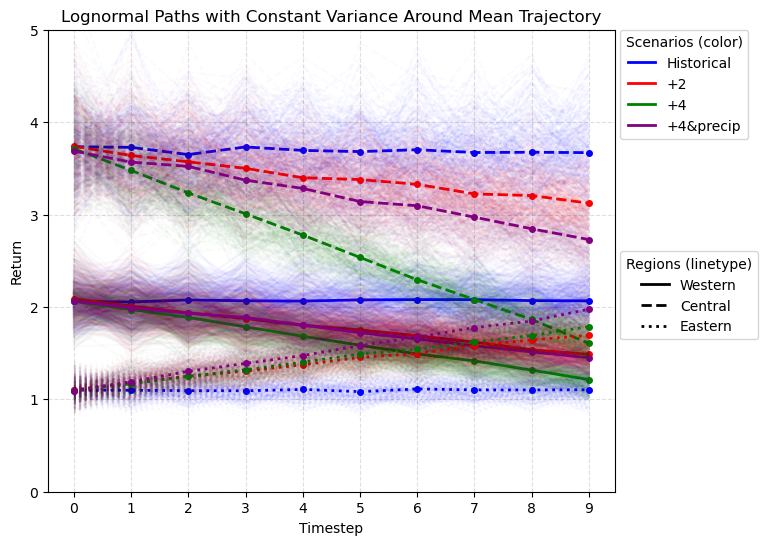

In [91]:
# Simulate paths that transition from present to future levels (consistent with Cell 3)
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np

# load data
baseline_returns = np.array([
    [2.07, 1.49, 1.21, 1.44],  # Western
    [3.70, 3.11, 1.61, 2.74],  # Central
    [1.10, 1.72, 1.78, 1.96],  # Eastern
])  # col 0: historical, col 1-3: future scenarios
central_adjustment = 0
baseline_returns[1] = baseline_returns[1] - central_adjustment

timesteps = 10
multi_timestep_returns = np.zeros((timesteps,) + baseline_returns.shape)
multi_timestep_returns[-1] = baseline_returns

multi_timestep_returns[0] = np.tile(baseline_returns[:, 0], (4, 1)).T
historical_col = baseline_returns[:, 0][:, np.newaxis]
for t in range(1, timesteps - 1):
    multi_timestep_returns[t] = historical_col + (baseline_returns - historical_col) * t / (timesteps - 1)

# Lognormal simulations around mean path with constant variance (Section 3.2 style)
num_simulations = 300
sigma_logn = 0.1  # constant std dev in log space across all timesteps/regions/scenarios
mean_path = np.clip(multi_timestep_returns, 1e-6, None)
log_mu = np.log(mean_path) - 0.5 * sigma_logn**2

simulations = np.random.lognormal(
    mean=log_mu[..., np.newaxis],
    sigma=sigma_logn,
    size=(timesteps,) + baseline_returns.shape + (num_simulations,)
    )

# Plot mean path per region/scenario plus faint simulation paths
fig, ax = plt.subplots(figsize=(11, 6))
scenario_colors = ['blue', 'red', 'green', 'purple']
region_linetype = ['-', '--', ':']
region_names = ['Western', 'Central', 'Eastern']
x = np.arange(timesteps)

for region in range(baseline_returns.shape[0]):
    for scenario in range(baseline_returns.shape[1]):
        for i in range(num_simulations):
            ax.plot(
                x,
                simulations[:, region, scenario, i],
                color=scenario_colors[scenario],
                alpha=0.02,
                linestyle=region_linetype[region]
            )
        ax.plot(
            x,
            simulations[:, region, scenario, :].mean(axis=1),
            color=scenario_colors[scenario],
            linestyle=region_linetype[region],
            linewidth=2,
            marker='o',
            markersize=4
        )

# Separate legends: colors for scenarios, linetypes for regions
scenario_names = ['Historical', '+2', '+4', '+4&precip']
scenario_handles = [
    Line2D([0], [0], color=scenario_colors[s], lw=2, label=f'{scenario_names[s]}')
    for s in range(baseline_returns.shape[1])
]
region_handles = [
    Line2D([0], [0], color='black', lw=2, linestyle=region_linetype[r], label=region_names[r])
    for r in range(baseline_returns.shape[0])
]

legend_scenarios = ax.legend(
    handles=scenario_handles,
    title='Scenarios (color)',
    loc='upper left',
    bbox_to_anchor=(1.01, 1.0),
    borderaxespad=0.0
)
ax.add_artist(legend_scenarios)
ax.legend(
    handles=region_handles,
    title='Regions (linetype)',
    loc='upper left',
    bbox_to_anchor=(1.01, 0.52),
    borderaxespad=0.0
)

ax.set_ylim(0, 5)
ax.set_xlabel('Timestep')
ax.set_ylabel('Return')
ax.set_title('Lognormal Paths with Constant Variance Around Mean Trajectory')
ax.set_xticks(x)
ax.grid(True, which='major', linestyle='--', alpha=0.4)

# Reserve extra space on the right so legends are fully visible in notebook output
fig.subplots_adjust(right=0.64)
plt.show()

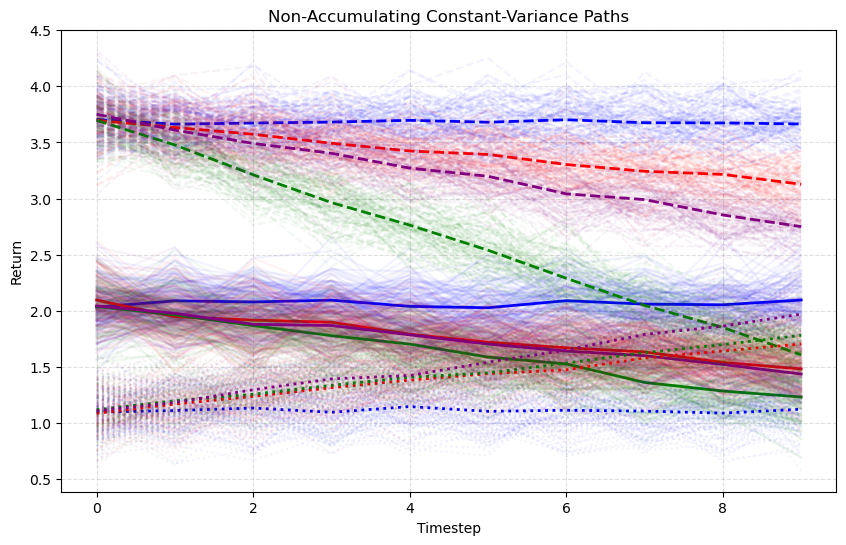

In [ ]:
# Non-accumulating version: constant variance at each timestep around the mean path
import matplotlib.pyplot as plt
import numpy as np

# Reuse existing baseline_returns / multi_timestep_returns if available
if 'multi_timestep_returns' not in globals():
    baseline_returns = np.array([
        [2.07, 1.49, 1.21, 1.44],
        [3.70, 3.11, 1.61, 2.74],
        [1.10, 1.72, 1.78, 1.96],
    ])
    timesteps = 10
    multi_timestep_returns = np.zeros((timesteps,) + baseline_returns.shape)
    multi_timestep_returns[-1] = baseline_returns
    multi_timestep_returns[0] = np.tile(baseline_returns[:, 0], (4, 1)).T
    historical_col = baseline_returns[:, 0][:, np.newaxis]
    for t in range(1, timesteps - 1):
        multi_timestep_returns[t] = historical_col + (baseline_returns - historical_col) * t / (timesteps - 1)

timesteps = multi_timestep_returns.shape[0]
n_regions, n_scenarios = multi_timestep_returns.shape[1], multi_timestep_returns.shape[2]
num_simulations = 100
sigma_const = 0.2

# Each timestep is sampled independently: X_t = mean_t + sigma * epsilon_t
noise = np.random.normal(0, sigma_const, size=(timesteps, n_regions, n_scenarios, num_simulations))
simulations_const = multi_timestep_returns[..., np.newaxis] + noise

plt.figure(figsize=(10, 6))
scenario_colors = ['blue', 'red', 'green', 'purple']
region_linetype = ['-', '--', ':']

for region in range(n_regions):
    for scenario in range(n_scenarios):
        for i in range(num_simulations):
            plt.plot(
                simulations_const[:, region, scenario, i],
                color=scenario_colors[scenario],
                alpha=0.05,
                linestyle=region_linetype[region]
            )
        plt.plot(
            simulations_const[:, region, scenario, :].mean(axis=1),
            color=scenario_colors[scenario],
            linestyle=region_linetype[region],
            linewidth=2
        )

plt.xlabel('Timestep')
plt.ylabel('Return')
plt.title('Non-Accumulating Constant-Variance Paths')
plt.grid(True, which='major', linestyle='--', alpha=0.4)
plt.show()

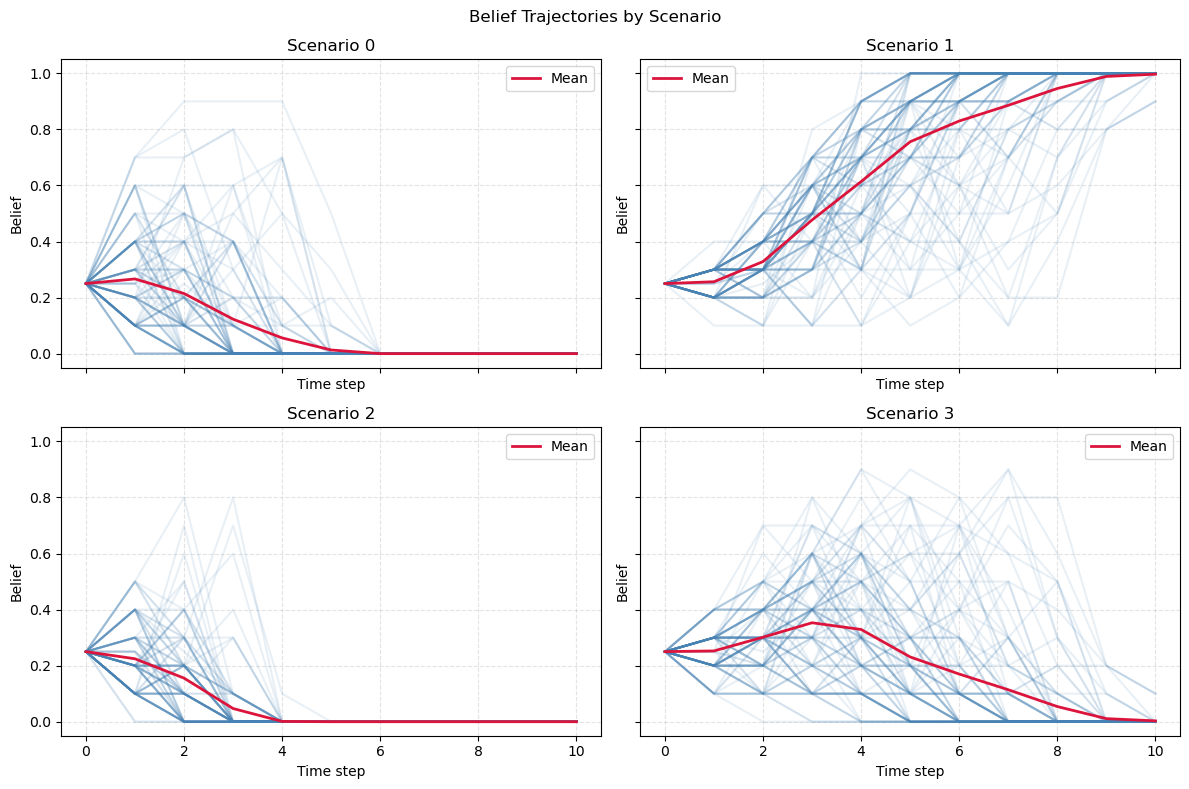

In [19]:
from pprdyn1 import *
import numpy as np
import matplotlib.pyplot as plt

env = pprdyn1({'settingID': 11})
testing_scenario = 1
episodenum = 100
beliefs = np.zeros((episodenum, env.n_scenario, env.T + 1))

for i in range(episodenum):
    env.reset(scenario=testing_scenario)
    done = False
    beliefs[i, :, 0] = env.state[env.sidx['b']]
    while not done:
        action = 0
        obs, reward, done, info = env.step(action)
        beliefs[i, :, int(env.state[env.sidx['t']].item())] = env.state[env.sidx['b']]

# Plot all scenarios in a 2x2 grid
n_scenarios = env.n_scenario
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
axes = axes.ravel()

for s in range(n_scenarios):
    ax = axes[s]
    for i in range(episodenum):
        ax.plot(range(env.T + 1), beliefs[i, s, :], alpha=0.12, color='steelblue')

    mean_belief = beliefs[:, s, :].mean(axis=0)
    ax.plot(range(env.T + 1), mean_belief, color='crimson', linewidth=2, label='Mean')
    ax.set_title(f'Scenario {s}')
    ax.set_xlabel('Time step')
    ax.set_ylabel('Belief')
    ax.grid(True, linestyle='--', alpha=0.35)
    ax.legend(loc='best')

# Hide any extra axes if scenario count is not 4
for ax in axes[n_scenarios:]:
    ax.set_visible(False)

plt.suptitle('Belief Trajectories by Scenario')
plt.tight_layout()
plt.show()

In [3]:
# evaluate performance of different policies
from pprdyn1 import *
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import pickle
import numpy as np
import pandas as pd
from performance_eval import avgperformance
# from VI_pprdyn1 import _act, build_optimal_controller_fully_observable

config = {'policytype': 0, 'VIenvsetting': 0,'num_episodes': 10000}
settings = {'settingID': 3}
env = pprdyn1(settings)
summary = avgperformance(env,config=config, policy_printout=False,printout = False)


policy type: value iteration
Episode 1000 done
Episode 2000 done
Episode 3000 done
Episode 4000 done
Episode 5000 done
Episode 6000 done
Episode 7000 done
Episode 8000 done
Episode 9000 done
Episode 10000 done
MC log_negV = -8.533102
Average reward over 10000 episodes: -9.5138, certrainty equivalent: 2.6099


In [2]:
# evaluate performance of different policies
from pprdyn1 import *
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import pickle
import numpy as np
import pandas as pd
from performance_eval import avgperformance

for n in [2]:
    for i in [1,2,3,4,7,8,9,10,12,13,14,15]:
        #np.random.seed(42)
        config = {'policytype': n, 'num_episodes': 10000}
        settings = {'settingID': i}
        env = pprdyn1(settings)
        summary = avgperformance(env, config)

policy type: static E utility optimization on final timestep not updating the belief
Episode 1000 done
Episode 2000 done
Episode 3000 done
Episode 4000 done
Episode 5000 done
Episode 6000 done
Episode 7000 done
Episode 8000 done
Episode 9000 done
Episode 10000 done
MC log_negV = -1.079103
Average reward over 10000 episodes: -1.0932, certrainty equivalent: 3.8268
policy type: static E utility optimization on final timestep not updating the belief
Episode 1000 done
Episode 2000 done
Episode 3000 done
Episode 4000 done
Episode 5000 done
Episode 6000 done
Episode 7000 done
Episode 8000 done
Episode 9000 done
Episode 10000 done
MC log_negV = -2.871908
Average reward over 10000 episodes: -2.9740, certrainty equivalent: 2.5752
policy type: static E utility optimization on final timestep not updating the belief
Episode 1000 done
Episode 2000 done
Episode 3000 done
Episode 4000 done
Episode 5000 done
Episode 6000 done
Episode 7000 done
Episode 8000 done
Episode 9000 done
Episode 10000 done
MC l

In [21]:
from VIpprdyn1 import *

vi = VIpprdyn1(settings={'settingID': 14})
vi.precompute_belief_transitions()

Precomputing belief transitions (setting=14)...
Precomputing belief transitions completed in 14.83 minutes.


policy type: value iteration
MC log_negV = -14.004674
Average reward over 200 episodes: -17.9608, certrainty equivalent: 2.0199
policy type: static E utility optimization on final timestep not updating the belief
MC log_negV = -9.234206
Average reward over 1 episodes: -9.2342, certrainty equivalent: 1.5714


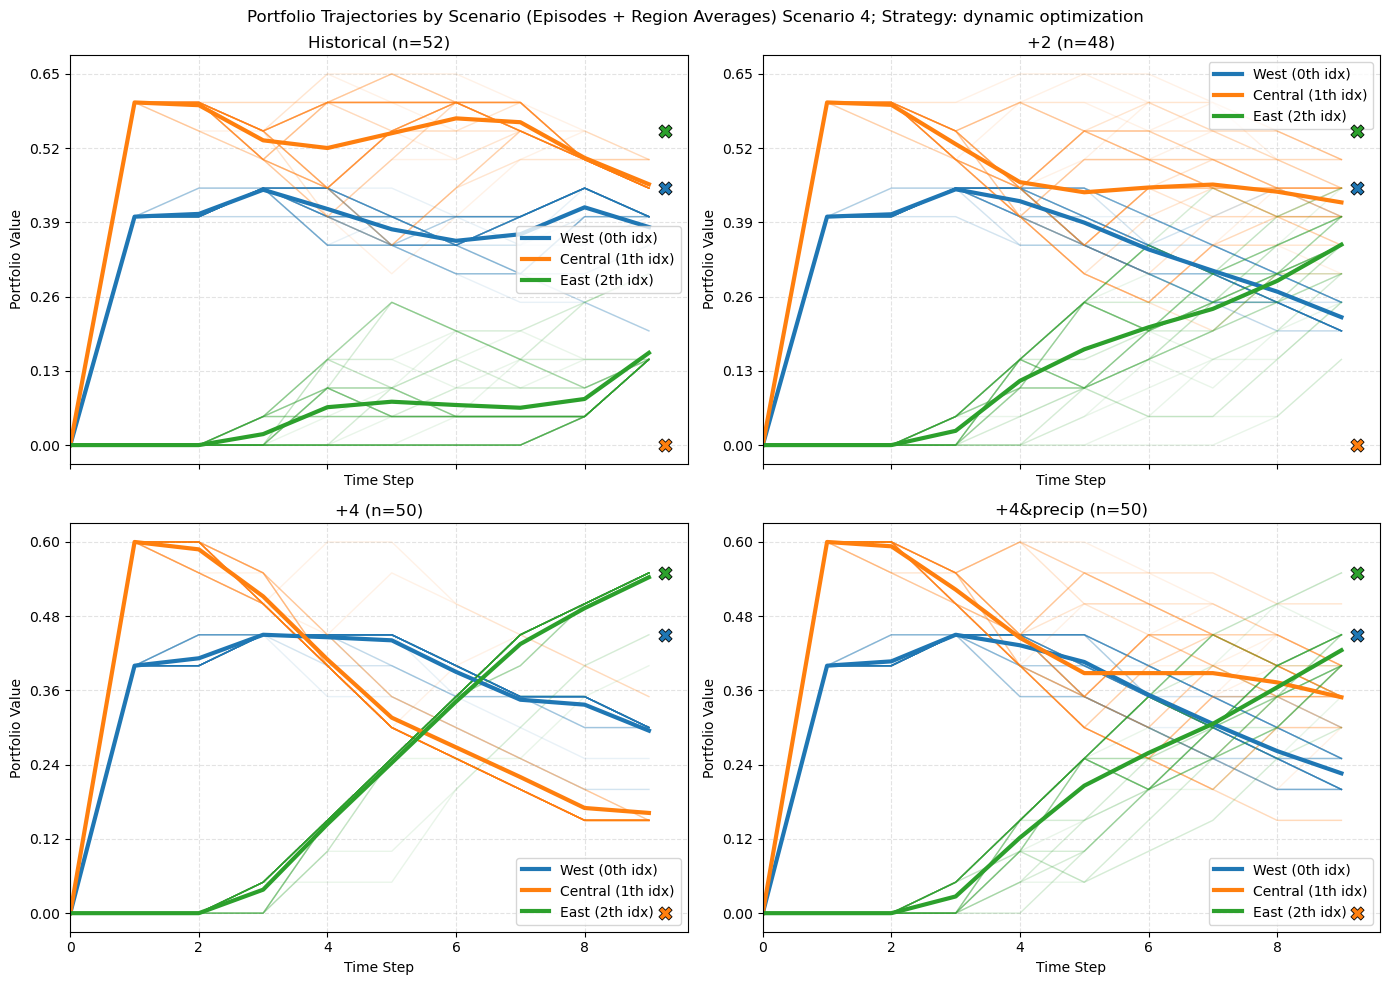

In [35]:
# analyze VI
import numpy as np
import matplotlib.pyplot as plt
from performance_eval import *

#np.random.seed(42)
config = {'policytype': 0, 'num_episodes': 200}
settings = {'settingID': 4}
env = pprdyn1(settings)
summary = avgperformance(env, config, collect_data=True)

# get policy of fixed terminal static with no belief update
config2 = {'policytype': 2, 'num_episodes': 1}
summary2 = avgperformance(env, config2, collect_data=True)
portfolios2 = np.asarray(summary2['allocations'][0, 0, :]).reshape(-1)

# Convert to array: expected shape (episodes, time, regions)
portfolios = np.asarray(summary['portfolios'])
if portfolios.ndim == 2:
    # fallback: treat as single series if regions are not present
    portfolios = portfolios[..., np.newaxis]

# Get episode indices grouped by scenario
scenario_indices = {}
for s in range(env.n_scenario):
    scenario_indices[s] = []
    for ep in range(config['num_episodes']):
        # Extract scenario state as a scalar to avoid NumPy scalar-conversion deprecation warnings
        s_val = np.asarray(summary['states'][ep, 0, env.sidx['s']]).reshape(-1)[0]
        if int(s_val) == s:
            scenario_indices[s].append(ep)

# Region mapping for legend/colors
region_names = ['West', 'Central', 'East']
scenario_names = ['Historical', '+2', '+4', '+4&precip']
region_colors = ['tab:blue', 'tab:orange', 'tab:green']
policy_names = ['dynamic optimization', 'rolling static MPT']
n_regions = min(portfolios.shape[2], len(region_names), portfolios2.shape[0])

# 2x2 subplot: one panel per scenario
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=False)
axes = axes.ravel()

for s in range(min(4, env.n_scenario)):
    ax = axes[s]
    ep_idx = scenario_indices[s]

    if len(ep_idx) == 0:
        ax.set_title(f'Scenario {s} (no episodes)')
        ax.grid(True, linestyle='--', alpha=0.35)
        continue

    scenario_paths = portfolios[ep_idx, :, :n_regions]  # (n_eps, time, n_regions)
    t_end = scenario_paths.shape[1] - 1
    x_alloc = t_end + 0.25

    # Plot each episode path lightly, colored by region
    for r in range(n_regions):
        for k in range(scenario_paths.shape[0]):
            ax.plot(
                scenario_paths[k, :, r],
                color=region_colors[r],
                alpha=0.10,
                linewidth=1
            )

    # Plot average path boldly for each region
    for r in range(n_regions):
        mean_path_r = scenario_paths[:, :, r].mean(axis=0)
        ax.plot(
            mean_path_r,
            color=region_colors[r],
            linewidth=3,
            label=f'{region_names[r]} ({r}th idx)'
        )

    # Add portfolios2 allocation at the end of x-axis using same region colors
    for r in range(n_regions):
        ax.scatter(
            x_alloc,
            portfolios2[r],
            color=region_colors[r],
            marker='X',
            s=90,
            edgecolors='black',
            linewidths=0.6,
            zorder=6
        )

    # Ensure y-ticks are visible on every subplot
    local_min = np.nanmin(scenario_paths)
    local_max = np.nanmax(scenario_paths)
    if np.isfinite(local_min) and np.isfinite(local_max) and local_max > local_min:
        y_ticks = np.linspace(local_min, local_max, 6)
        ax.set_yticks(y_ticks)

    ax.set_xlim(0, x_alloc + 0.35)
    ax.set_title(f'{scenario_names[s]} (n={len(ep_idx)})')
    ax.set_xlabel('Time Step')
    ax.set_ylabel('Portfolio Value')
    ax.tick_params(axis='y', labelleft=True)
    ax.grid(True, linestyle='--', alpha=0.35)
    ax.legend(loc='best')

# Hide extra panels if scenario count < 4
for s in range(min(4, env.n_scenario), 4):
    axes[s].set_visible(False)

plt.suptitle(f'Portfolio Trajectories by Scenario (Episodes + Region Averages) Scenario {settings["settingID"]}; Strategy: {policy_names[config["policytype"]]}')
plt.tight_layout()
plt.show()

policy type: static E utility optimization on final timestep not updating the belief
MC log_negV = -0.945993
Average reward over 1 episodes: -0.9460, certrainty equivalent: 3.5804
policy type: value iteration
MC log_negV = -1.788901
Average reward over 60 episodes: -1.8242, certrainty equivalent: 5.4571
policy type: rolling E utility optimization on next year returns
MC log_negV = -1.786936
Average reward over 60 episodes: -1.8342, certrainty equivalent: 5.4518
policy type: static E utility optimization on final timestep not updating the belief
MC log_negV = -11.474545
Average reward over 1 episodes: -11.4745, certrainty equivalent: 1.7681
policy type: value iteration
MC log_negV = -15.331092
Average reward over 60 episodes: -18.2865, certrainty equivalent: 2.1660
policy type: rolling E utility optimization on next year returns
MC log_negV = -15.247139
Average reward over 60 episodes: -18.1583, certrainty equivalent: 2.1564


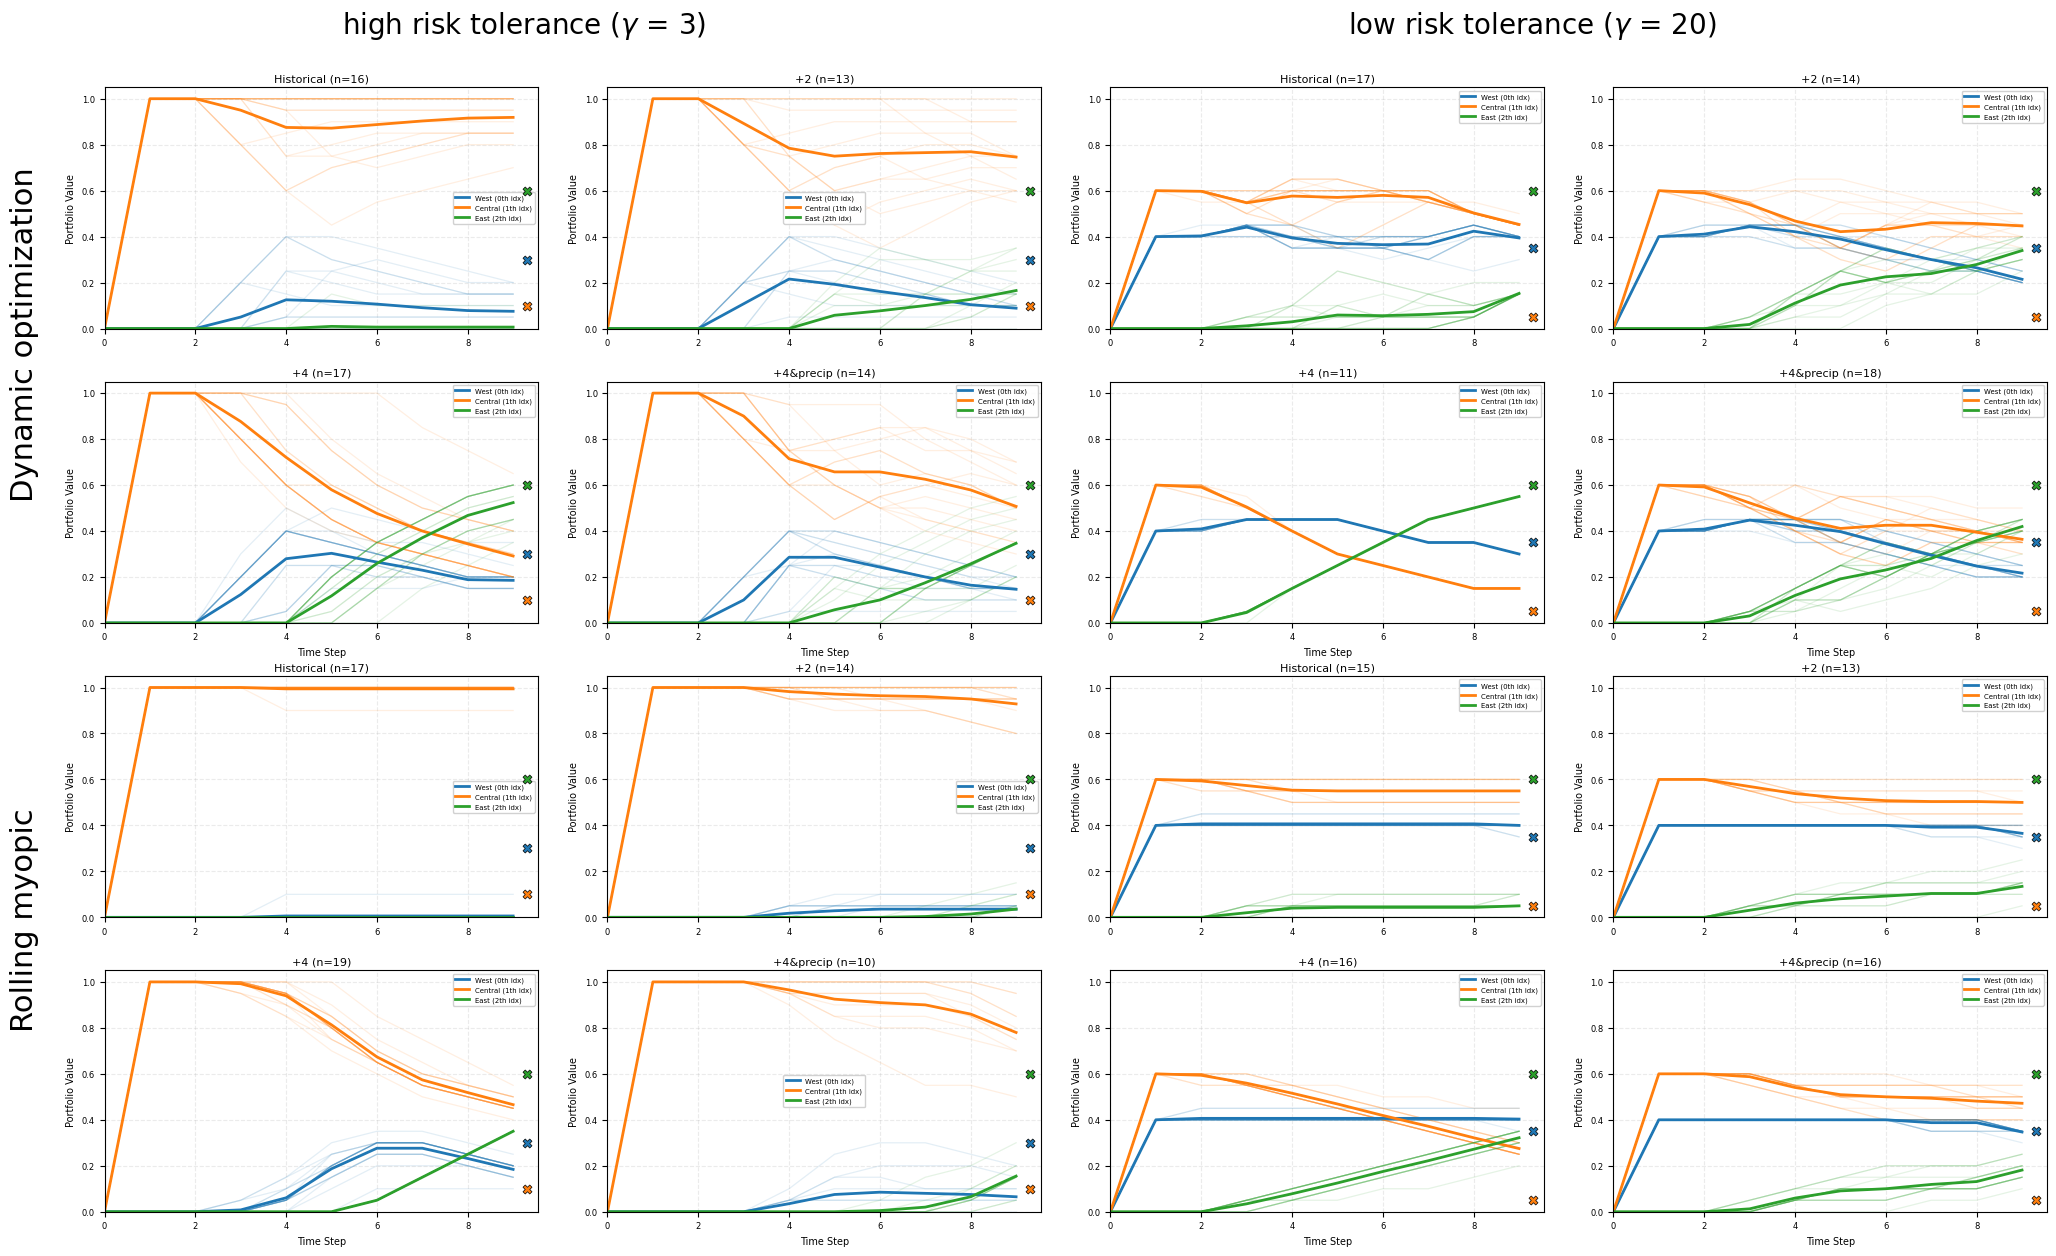

0.6
1.0


In [3]:
# Composite figure: 2 gamma settings x 2 policy types, each with 2x2 scenario panels
import numpy as np
import matplotlib.pyplot as plt
from performance_eval import avgperformance
from pprdyn1 import pprdyn1

# ---------- user-tunable settings ----------
gamma_panels = [
    {'settingID': 1, 'title': r'high risk tolerance ($\gamma$ = 3)'},
    {'settingID': 4, 'title': r'low risk tolerance ($\gamma$ = 20)'},
]
policy_panels = [
    {'policytype': 0, 'label': 'Dynamic optimization'},
    {'policytype': 1, 'label': 'Rolling myopic'},
]
num_episodes = 60
scenario_names = ['Historical', '+2', '+4', '+4&precip']
region_names = ['West', 'Central', 'East']
region_colors = ['tab:blue', 'tab:orange', 'tab:green']

# ---------- plotting ----------
fig, axes = plt.subplots(4, 4, figsize=(21, 13), sharex=False, sharey=False)

for col, gamma_cfg in enumerate(gamma_panels):
    env = pprdyn1({'settingID': gamma_cfg['settingID']})

    # Static allocation marker (X at end of x-axis)
    static_cfg = {'policytype': 2, 'num_episodes': 1}
    static_summary = avgperformance(env, static_cfg, collect_data=True)
    static_alloc = np.asarray(static_summary['allocations'][0, 0, :]).reshape(-1)

    for row, policy_cfg in enumerate(policy_panels):
        config = {'policytype': policy_cfg['policytype'], 'num_episodes': num_episodes}
        summary = avgperformance(env, config, collect_data=True)
        portfolios = np.asarray(summary['portfolios'])

        # Ensure shape (episodes, time, regions)
        if portfolios.ndim == 2:
            portfolios = portfolios[..., np.newaxis]

        n_regions = min(portfolios.shape[2], len(region_names), static_alloc.shape[0])

        # Group episode indices by scenario
        scenario_indices = {s: [] for s in range(env.n_scenario)}
        for ep in range(config['num_episodes']):
            s_val = np.asarray(summary['states'][ep, 0, env.sidx['s']]).reshape(-1)[0]
            s_idx = int(s_val)
            if s_idx in scenario_indices:
                scenario_indices[s_idx].append(ep)

        # Fill the 2x2 scenario block
        for s in range(4):
            rr = row * 2 + (s // 2)
            cc = col * 2 + (s % 2)
            ax = axes[rr, cc]

            ep_idx = scenario_indices.get(s, [])
            if len(ep_idx) == 0:
                ax.set_title(f'{scenario_names[s]} (n=0)', fontsize=8, pad=4)
                ax.set_ylim(0, 2.1)
                ax.set_yticks(np.linspace(0, 2.1, 6))
                ax.grid(True, linestyle='--', alpha=0.25)
                continue

            scenario_paths = portfolios[ep_idx, :, :n_regions]  # (n_eps, T, n_regions)
            t_end = scenario_paths.shape[1] - 1
            x_alloc = t_end + 0.30

            # Faint episode paths
            for r in range(n_regions):
                for k in range(scenario_paths.shape[0]):
                    ax.plot(
                        scenario_paths[k, :, r],
                        color=region_colors[r],
                        alpha=0.12,
                        linewidth=0.9
                    )

            # Bold mean lines
            for r in range(n_regions):
                mean_path = scenario_paths[:, :, r].mean(axis=0)
                ax.plot(
                    mean_path,
                    color=region_colors[r],
                    linewidth=2.0,
                    label=f'{region_names[r]} ({r}th idx)'
                )

            # Static allocation marker at end of x-axis
            for r in range(n_regions):
                ax.scatter(
                    x_alloc,
                    static_alloc[r],
                    color=region_colors[r],
                    marker='X',
                    s=42,
                    edgecolors='black',
                    linewidths=0.5,
                    zorder=6
                )

            # Axes/labels
            ax.set_ylim(0, 1.05)
            ax.set_yticks(np.linspace(0, 1, 6))
            ax.set_xlim(0, x_alloc + 0.25)
            ax.set_title(f'{scenario_names[s]} (n={len(ep_idx)})', fontsize=8, pad=4)

            # Show x-label only on the bottom row of each 2x2 block to avoid overlap with titles below
            if rr in [1, 3]:
                ax.set_xlabel('Time Step', fontsize=7)
            else:
                ax.set_xlabel('')

            ax.set_ylabel('Portfolio Value', fontsize=7)
            ax.tick_params(axis='both', labelsize=6)
            ax.grid(True, linestyle='--', alpha=0.25)
            ax.legend(loc='best', fontsize=5, framealpha=0.9)

# Column headers (gamma)
fig.text(0.26, 0.98, gamma_panels[0]['title'], ha='center', va='top', fontsize=20)
fig.text(0.74, 0.98, gamma_panels[1]['title'], ha='center', va='top', fontsize=20)

# Row headers (policy)
fig.text(0.015, 0.73, policy_panels[0]['label'], rotation=90, va='center', ha='left', fontsize=22)
fig.text(0.015, 0.28, policy_panels[1]['label'], rotation=90, va='center', ha='left', fontsize=22)

# Keep enough gutter between major panels
fig.subplots_adjust(left=0.06, right=0.985, top=0.92, bottom=0.055, wspace=0.16, hspace=0.22)

plt.show()

print(np.max(portfolios[:, :, 1]))
print(np.max(portfolios.sum(axis=2)))

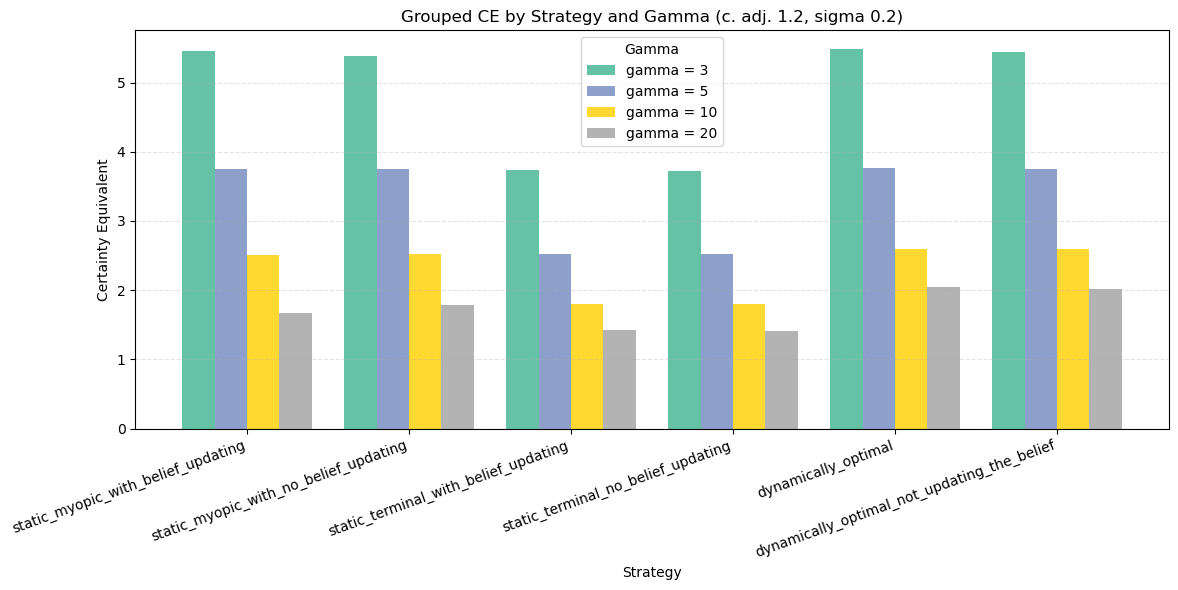

In [5]:
# bar plot of ce results
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

filename = './results/ce_results.csv'
df_raw = pd.read_csv(filename)
settingids = np.array([1,2,3,4])
setting_text_options = ['c. adj. 1.2, sigma 0.2', 'c. adj. 0 sigma 0.2', 'c. adj. 1.2 sigma 0.1']
if np.all(settingids == np.array([1, 2, 3, 4])):
    setting_texts = setting_text_options[0]
elif np.all(settingids == np.array([7,8,9,10])):
    setting_texts = setting_text_options[1]
elif np.all(settingids == np.array([12,13,14,15])):
    setting_texts = setting_text_options[2]


# Normalize column names so lookups are robust to case/spacing
normalized_cols = [
    str(c).strip().lower().replace(' ', '_').replace('-', '_')
    for c in df_raw.columns
]
df = df_raw.copy()
df.columns = normalized_cols

# Resolve expected key columns
if 'setting' not in df.columns:
    for alt in ['settings', 'settingid', 'setting_id']:
        if alt in df.columns:
            df = df.rename(columns={alt: 'setting'})
            break

if 'gamma' not in df.columns:
    for alt in ['risk_aversion', 'riskaversion']:
        if alt in df.columns:
            df = df.rename(columns={alt: 'gamma'})
            break

if 'setting' not in df.columns:
    raise KeyError(f"Could not find 'setting' column. Available columns: {df.columns.tolist()}")
if 'gamma' not in df.columns:
    raise KeyError(f"Could not find 'gamma' column. Available columns: {df.columns.tolist()}")

# Filter to requested settings and keep rows ordered by gamma
df_plot = df[df['setting'].astype(int).isin(settingids)].copy()
df_plot = df_plot.sort_values('gamma').reset_index(drop=True)

# Columns from the 5th onward are strategy outcomes in your table
# (after: setting, sigma, central_adj, gamma)
if df_plot.shape[1] >= 5:
    strategy_cols = df_plot.columns[4:]
else:
    meta_cols = {'setting', 'sigma', 'central_adj', 'gamma'}
    strategy_cols = [c for c in df_plot.columns if c not in meta_cols and not c.startswith('unnamed')]

gamma_vals = df_plot['gamma'].astype(int).to_list()
n_strat = len(strategy_cols)
n_gamma = len(gamma_vals)
x = np.arange(n_strat)
width = 0.8 / max(n_gamma, 1)

fig, ax = plt.subplots(figsize=(12, 6))
colors = plt.cm.Set2(np.linspace(0, 1, n_gamma))

for i, g in enumerate(gamma_vals):
    y = df_plot.loc[i, strategy_cols].to_numpy(dtype=float)
    offset = (i - (n_gamma - 1) / 2) * width
    ax.bar(x + offset, y, width=width, color=colors[i], label=f'gamma = {g}')

ax.set_xticks(x)
ax.set_xticklabels(strategy_cols, rotation=20, ha='right')
ax.set_ylabel('Certainty Equivalent')
ax.set_xlabel('Strategy')
ax.set_title(f'Grouped CE by Strategy and Gamma ({setting_texts})')
ax.grid(axis='y', linestyle='--', alpha=0.35)
ax.legend(title='Gamma')
plt.tight_layout()
plt.show()

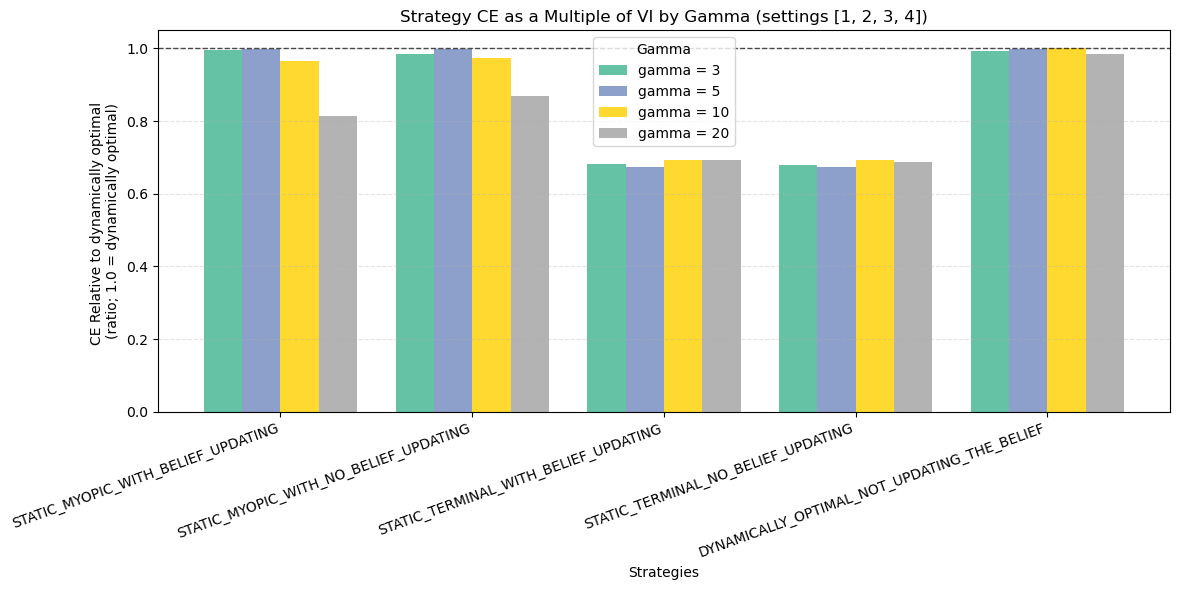

In [3]:
# Additional plot: CE ratios relative to a baseline strategy, excluding the baseline itself
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd



# Reuse df_plot and strategy_cols from Cell 19 if available; otherwise rebuild minimally
if 'df_plot' not in globals() or 'strategy_cols' not in globals():
    filename = './results/ce_results.csv'
    df_raw = pd.read_csv(filename)
    normalized_cols = [
        str(c).strip().lower().replace(' ', '_').replace('-', '_')
        for c in df_raw.columns
    ]
    df_tmp = df_raw.copy()
    df_tmp.columns = normalized_cols

    if 'setting' not in df_tmp.columns:
        for alt in ['settings', 'settingid', 'setting_id']:
            if alt in df_tmp.columns:
                df_tmp = df_tmp.rename(columns={alt: 'setting'})
                break

    if 'gamma' not in df_tmp.columns:
        for alt in ['risk_aversion', 'riskaversion']:
            if alt in df_tmp.columns:
                df_tmp = df_tmp.rename(columns={alt: 'gamma'})
                break

    if 'setting' not in df_tmp.columns or 'gamma' not in df_tmp.columns:
        raise KeyError(f"Required columns missing. Available columns: {df_tmp.columns.tolist()}")

    df_plot = df_tmp[df_tmp['setting'].astype(int).isin([1, 2, 3, 4])].copy()
    df_plot = df_plot.sort_values('gamma').reset_index(drop=True)

    if df_plot.shape[1] >= 5:
        strategy_cols = list(df_plot.columns[4:])
    else:
        meta_cols = {'setting', 'sigma', 'central_adj', 'gamma'}
        strategy_cols = [c for c in df_plot.columns if c not in meta_cols and not c.startswith('unnamed')]
else:
    strategy_cols = list(strategy_cols)

# Identify baseline column robustly
preferred_baselines = [
    'ce_vi',
    'dynamically_optimal',
    'dynamic_optimization',
]

vi_col = next((c for c in preferred_baselines if c in strategy_cols), None)

if vi_col is None:
    vi_col = next(
        (c for c in strategy_cols if 'dynamic' in str(c).lower() and 'optimal' in str(c).lower()),
        None
    )

if vi_col is None:
    raise KeyError(f"Could not find baseline strategy column within: {strategy_cols}")

plot_cols = [c for c in strategy_cols if c != vi_col]
if len(plot_cols) == 0:
    raise ValueError('No non-baseline strategy columns found to plot.')

# Compute CE ratios against baseline for each gamma row
vi_vals = df_plot[vi_col].to_numpy(dtype=float)
if np.any(np.isclose(vi_vals, 0.0)):
    raise ZeroDivisionError('Baseline CE has zeros; cannot compute CE/baseline ratios safely.')
ratio_df = df_plot[plot_cols].astype(float).div(df_plot[vi_col].astype(float), axis=0)

gamma_vals = df_plot['gamma'].astype(int).to_list()
n_strat = len(plot_cols)
n_gamma = len(gamma_vals)
x = np.arange(n_strat)
width = 0.8 / max(n_gamma, 1)

# Make title text robust even if Cell 19 has not been run
if 'setting_texts' in globals():
    setting_label = setting_texts
else:
    unique_settings = sorted(df_plot['setting'].astype(int).unique().tolist())
    setting_label = f'settings {unique_settings}'

fig, ax = plt.subplots(figsize=(12, 6))
colors = plt.cm.Set2(np.linspace(0, 1, n_gamma))

for i, g in enumerate(gamma_vals):
    y = ratio_df.iloc[i].to_numpy(dtype=float)
    offset = (i - (n_gamma - 1) / 2) * width
    ax.bar(x + offset, y, width=width, color=colors[i], label=f'gamma = {g}')

# Optional cleaner x labels
x_labels = [str(c).replace('ce_', '').upper() for c in plot_cols]
ax.set_xticks(x)
ax.set_xticklabels(x_labels, rotation=20, ha='right')
ax.axhline(1.0, color='black', linestyle='--', linewidth=1, alpha=0.7)
ax.set_ylabel('CE Relative to dynamically optimal \n(ratio; 1.0 = dynamically optimal)')
ax.set_xlabel('Strategies')
ax.set_title(f'Strategy CE as a Multiple of VI by Gamma ({setting_label})')
ax.grid(axis='y', linestyle='--', alpha=0.35)
ax.legend(title='Gamma')
plt.tight_layout()
plt.show()